# **Rauchbedingte Sterblichkeit in Deutschland im Jahr 2024**

## **Ziel:**   
Ziel dieser Analyse ist die Abschätzung der tabakassoziierten Sterblichkeit in Deutschland auf Basis der Todesursachenstatistik 2024 und epidemiologischer SAF-Werte.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Module importieren (bei Änderungen neu laden)
import analyse_sterbdaten_von_2024 as analyse
import sterblichkeit_analyse as sa

ANALYSE DER RAUCHBEDINGTEN STERBLICHKEIT IN DEUTSCHLAND
Deutschland, 2024

Daten erfolgreich geladen aus: statistischer-bericht-todesursachen-2120400247005.xlsx

Gesamtzahl aller Todesfälle: 1,007,758
Gesamtzahl Krebstodesfälle:  230,392

DETAILLIERTE ANALYSE DER RAUCHBEDINGTEN TODESURSACHEN
Ursache                             |       Gesamt |     Männer |     Frauen |    SAF |  Rauchen zurechenbar
--------------------------------------------------------------------------------------------------------------
Ischämische Herzkrankheiten         |      113,473 |     65,435 |     48,038 |   0.25 |               28,368
Schlaganfall                        |       52,185 |     23,523 |     28,662 |   0.18 |                9,393
Lungenkrebs                         |       45,148 |     26,441 |     18,707 |   0.88 |               39,730
Akuter Myokardinfarkt               |       41,258 |     24,875 |     16,383 |   0.00 |                    0
COPD (chronische Bronchitis/Emphysem) |       33,65

### **Datengrundlage**

Die Analyse basiert auf den Todesursachenstatistiken des Statistischen Bundesamtes für das Jahr 2024. Untersucht werden ausgewählte Erkrankungen, die in wissenschaftlichen Studien mit dem Tabakkonsum in Verbindung gebracht werden.    
Zur Abschätzung der tabakassoziierten Sterblichkeit wird das Smoking Attributable Fraction (SAF)-Modell verwendet.

### **1. Frage:** Welche dieser Erkrankungen verursachen die höchste Sterblichkeit?

In [2]:
metrics = analyse.calculate_key_metrics(analyse.df_total, analyse.total_deaths, analyse.total_cancer)
analyse.print_key_facts(metrics)
display(analyse.df_results)
print(f"\nGeschätzte tabakassoziierte Todesfälle: {analyse.df_results['Zugeschriebene_Todesfälle'].sum():,.0f}")

WICHTIGSTE FAKTEN AUF EINEN BLICK

 1 DIREKT MIT RAUCHEN VERBUNDENE ERKRANKUNGEN
   • Lungenkrebs:                     45,148
   • COPD:                            33,650
   • Speiseröhrenkrebs:                5,910
   • Bauchspeicheldrüsenkrebs:        19,533
   ─────────────────────────────────────────────
   GESAMT:                          104,241 (10.3% aller Todesfälle)

 2 HERZ-KREISLAUF-ERKRANKUNGEN
   • Ischämische Herzkrankheiten:    113,473
   • Akuter Myokardinfarkt:           41,258
   • Schlaganfall:                    52,185
   ─────────────────────────────────────────────
   GESAMT:                          165,658 (16.4% aller Todesfälle)

 3 GESAMTERGEBNIS
   Mit Rauchen direkt oder indirekt verbundene Todesfälle:
   269,899 Menschen
   Das entspricht 26.8% aller Todesfälle in Deutschland.

 4 KONTEXT
   • Alle Krebstodesfälle:   230,392
   • Anteil Lungenkrebs an Krebs: 19.6%
   • Ischämische Herzkrankheiten > alle Krebsarten zusammen: NEIN
   • Ischämische Herzkrank

,ICD,Ursache,Todesfälle_Gesamt,Todesfälle_Männer,Todesfälle_Frauen,SAF,Zugeschriebene_Todesfälle,Anteil_Gesamt_%,Anteil_Krebs_%
3,I20-I25,Ischämische Herzkrankheiten,113473,65435,48038,0.25,28368,11.26,NaN
4,I60-I69,Schlaganfall,52185,23523,28662,0.18,9393,5.18,NaN
0,C34,Lungenkrebs,45148,26441,18707,0.88,39730,4.48,19.60
2,I21,Akuter Myokardinfarkt,41258,24875,16383,0.00,0,4.09,NaN
1,J44,COPD (chronische Bronchitis/Emphysem),33650,17408,16242,0.80,26920,3.34,NaN
6,C25,Bauchspeicheldrüsenkrebs,19533,9844,9689,0.25,4883,1.94,8.48
5,C15,Speiseröhrenkrebs,5910,4498,1412,0.70,4137,0.59,2.57



Geschätzte tabakassoziierte Todesfälle: 113,431


### **2) Frage:** Wie viele Menschen starben im Jahr 2024 in Deutschland an ausgewählten Erkrankungen, die mit Rauchen in Verbindung stehen?

In [3]:
total_attributable = analyse.df_results['Zugeschriebene_Todesfälle'].sum()
#Anteil Zugeschriebene Todesausfälle zur gesamte Todesanzahl
anteil = (total_attributable /analyse.total_deaths * 100) 

In [4]:
print(f"Insgesamte Todesfälle: {analyse.total_deaths:,.0f}".replace(",", "."))
print(f"Krebs Todesfälle: {analyse.total_cancer:,.0f}".replace(",", "."))
print(f"Zugeschrieben Todesfälle: {total_attributable:,}.".replace(",", "."))
print(f"\nAnteil von Zugeschriebene Todesfälle:{anteil:.2f}%".replace(",", "."))

Insgesamte Todesfälle: 1.007.758
Krebs Todesfälle: 230.392
Zugeschrieben Todesfälle: 113.431.

Anteil von Zugeschriebene Todesfälle:11.26%


Etwa 113.431 Todesfälle (11,26 % aller Todesfälle) können 2024 statistisch dem Rauchen zugeschrieben werden.

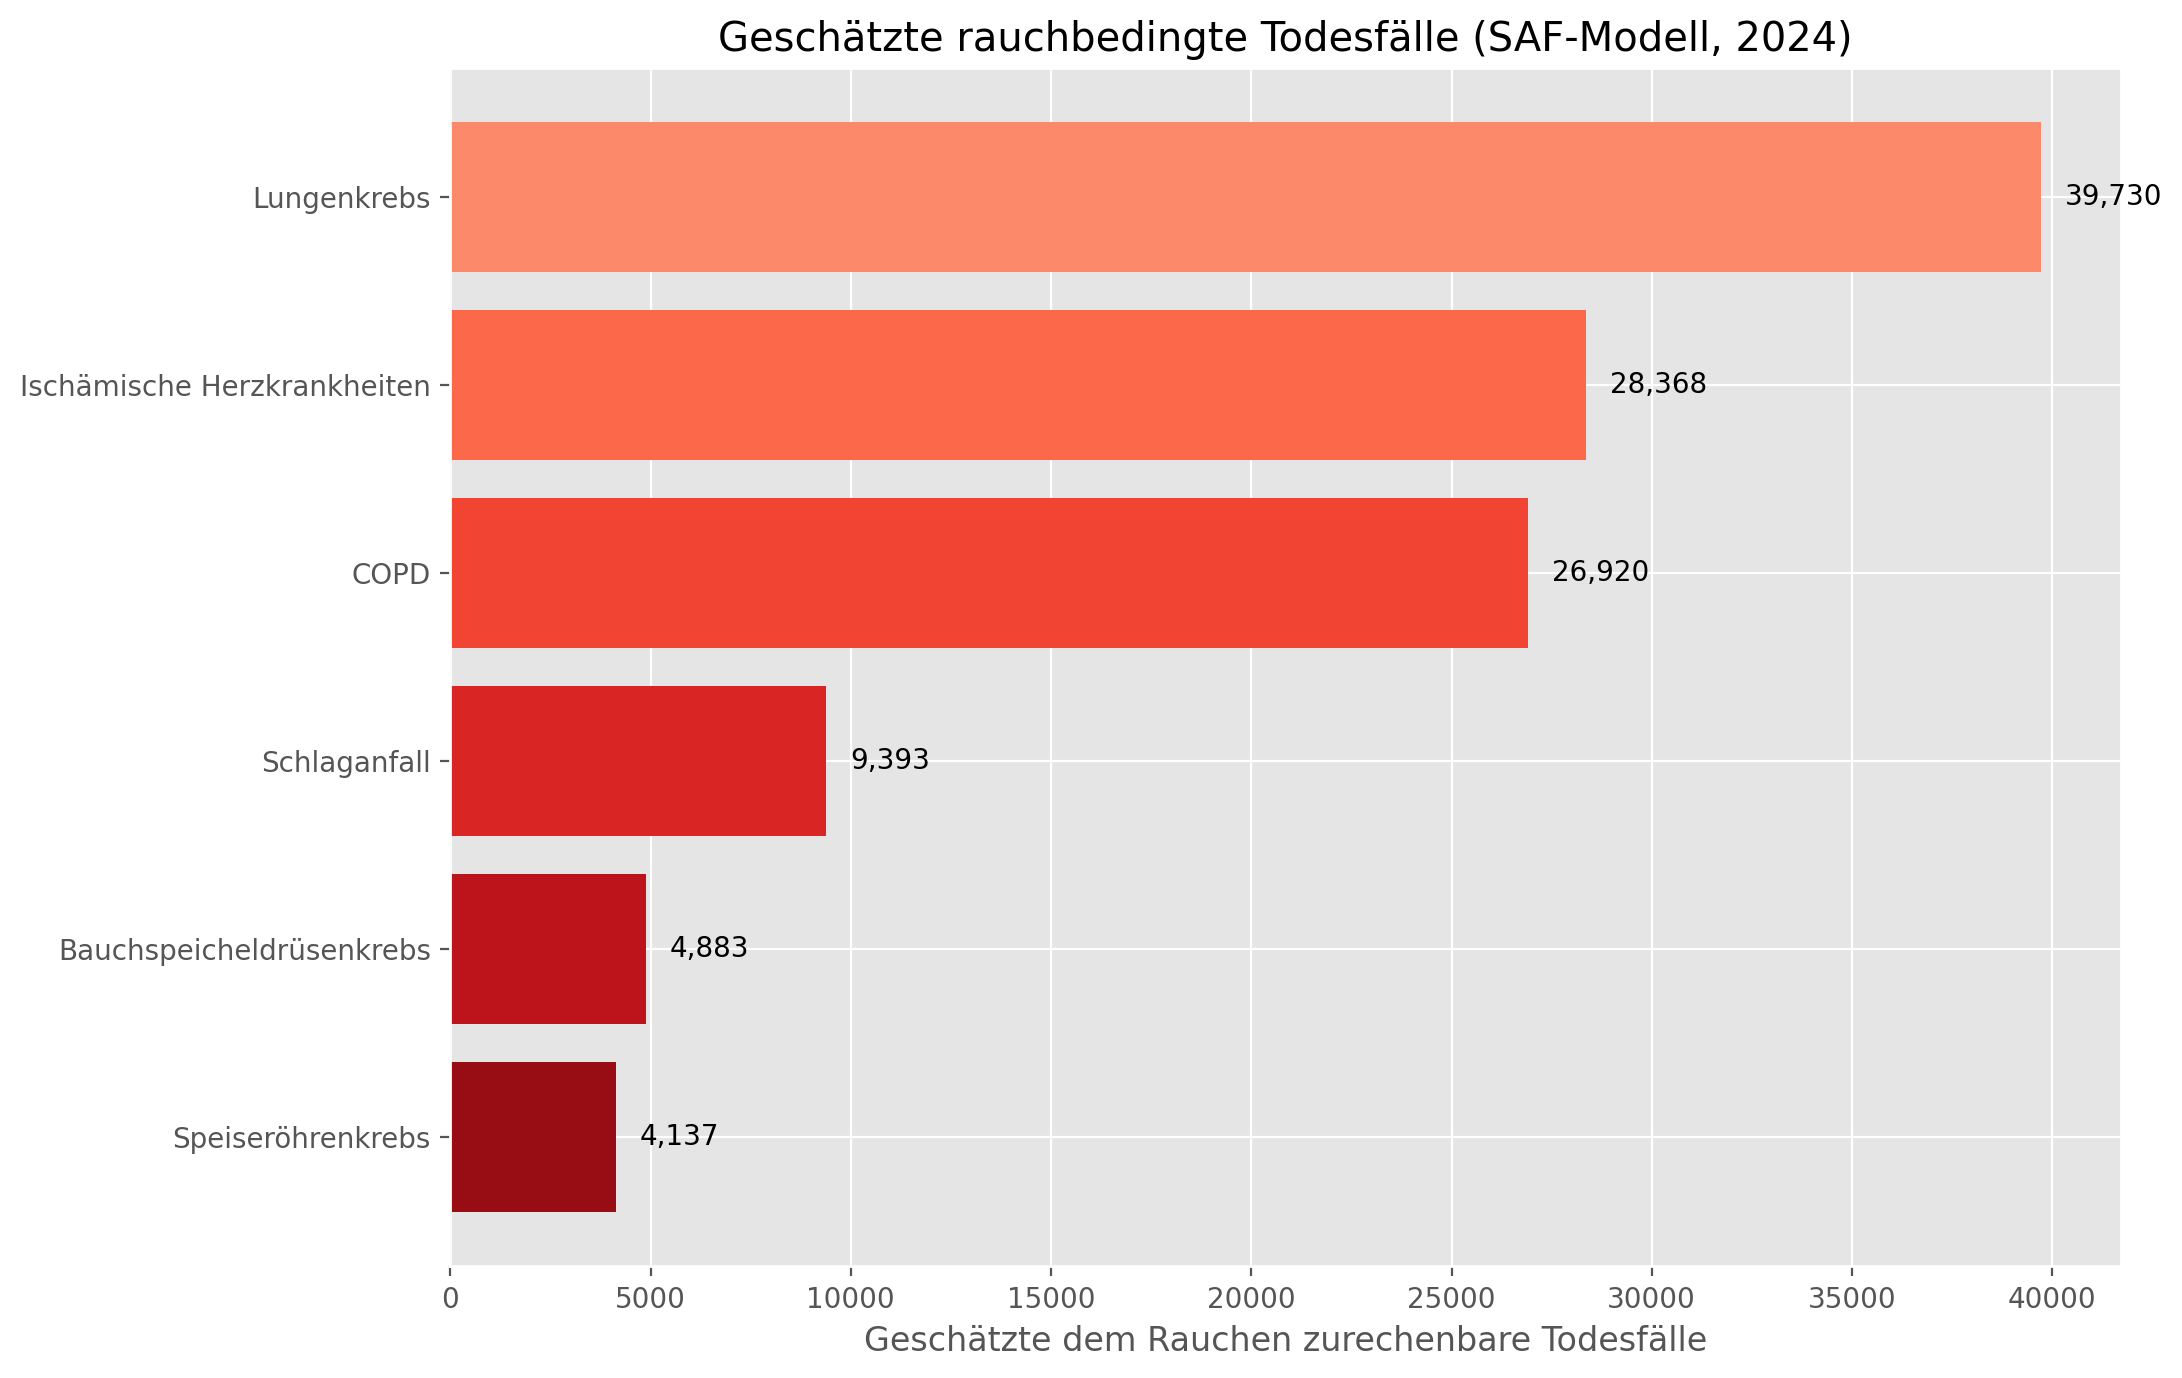

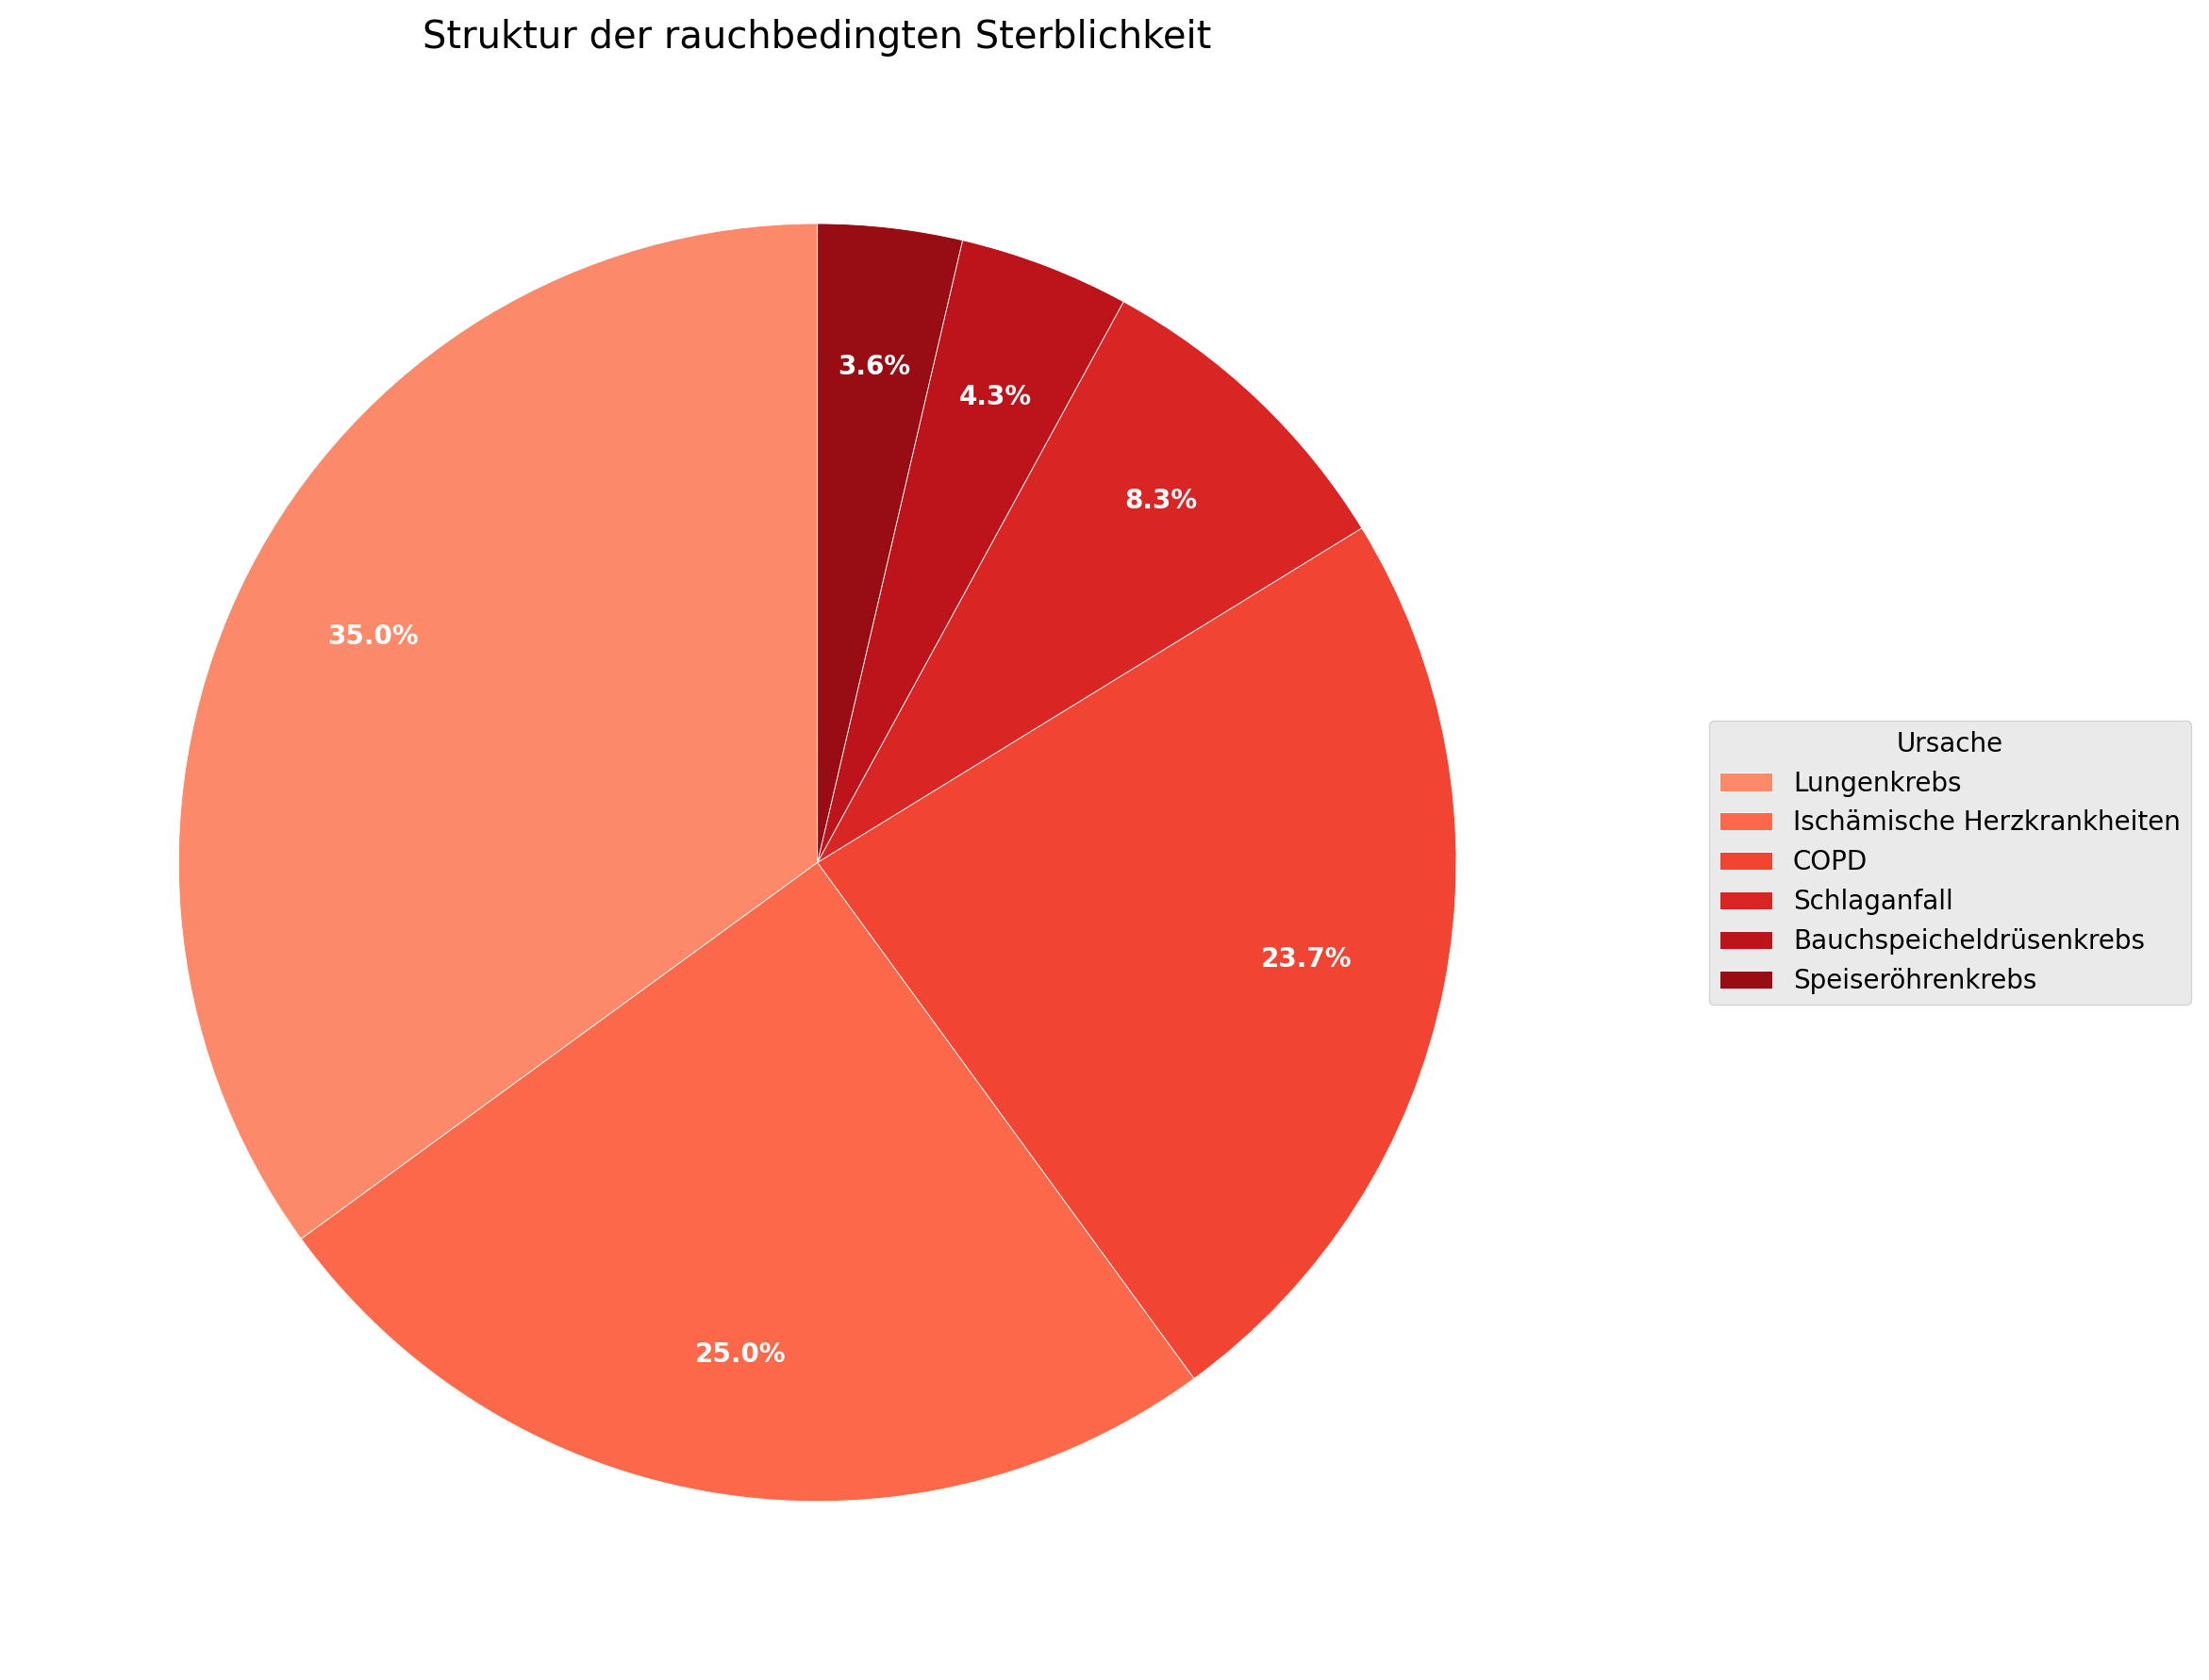

In [5]:
from IPython.display import Image, display

display(Image("Grafen/01_Zugeschriebene_Sterblichkeit.png"))
display(Image("Grafen/03_Struktur_Rauchbedingte_Sterblichkeit.png"))

Abbildung 1 zeigt die geschätzten tabakassoziierten Todesfälle der untersuchten Erkrankungen im Jahr 2024. Die Werte wurden mithilfe des Smoking Attributable Fraction (SAF)-Modells berechnet und stellen Schätzwerte dar.

In [6]:
from sterblichkeit_analyse import erstelle_interpretationsbericht
print(erstelle_interpretationsbericht(analyse.df_results, analyse.total_deaths))

INTERPRETATION DER ERGEBNISSE
--------------------------------------------------------------------------------

Hinweis: Die dargestellten rauchbedingten Todesfälle sind statistische Schätzwerte
auf Grundlage des Smoking Attributable Fraction (SAF)-Modells.
Geschätzte tabakassoziierte Todesfälle: 113.431
Anteil an allen Sterbefällen: 11.3%
Wichtigste tabakassoziierte Todesursache: Lungenkrebs


### **3) Frage:** Welche Unterschiede zeigen sich zwischen Männern und Frauen bei den untersuchten Todesursachen?

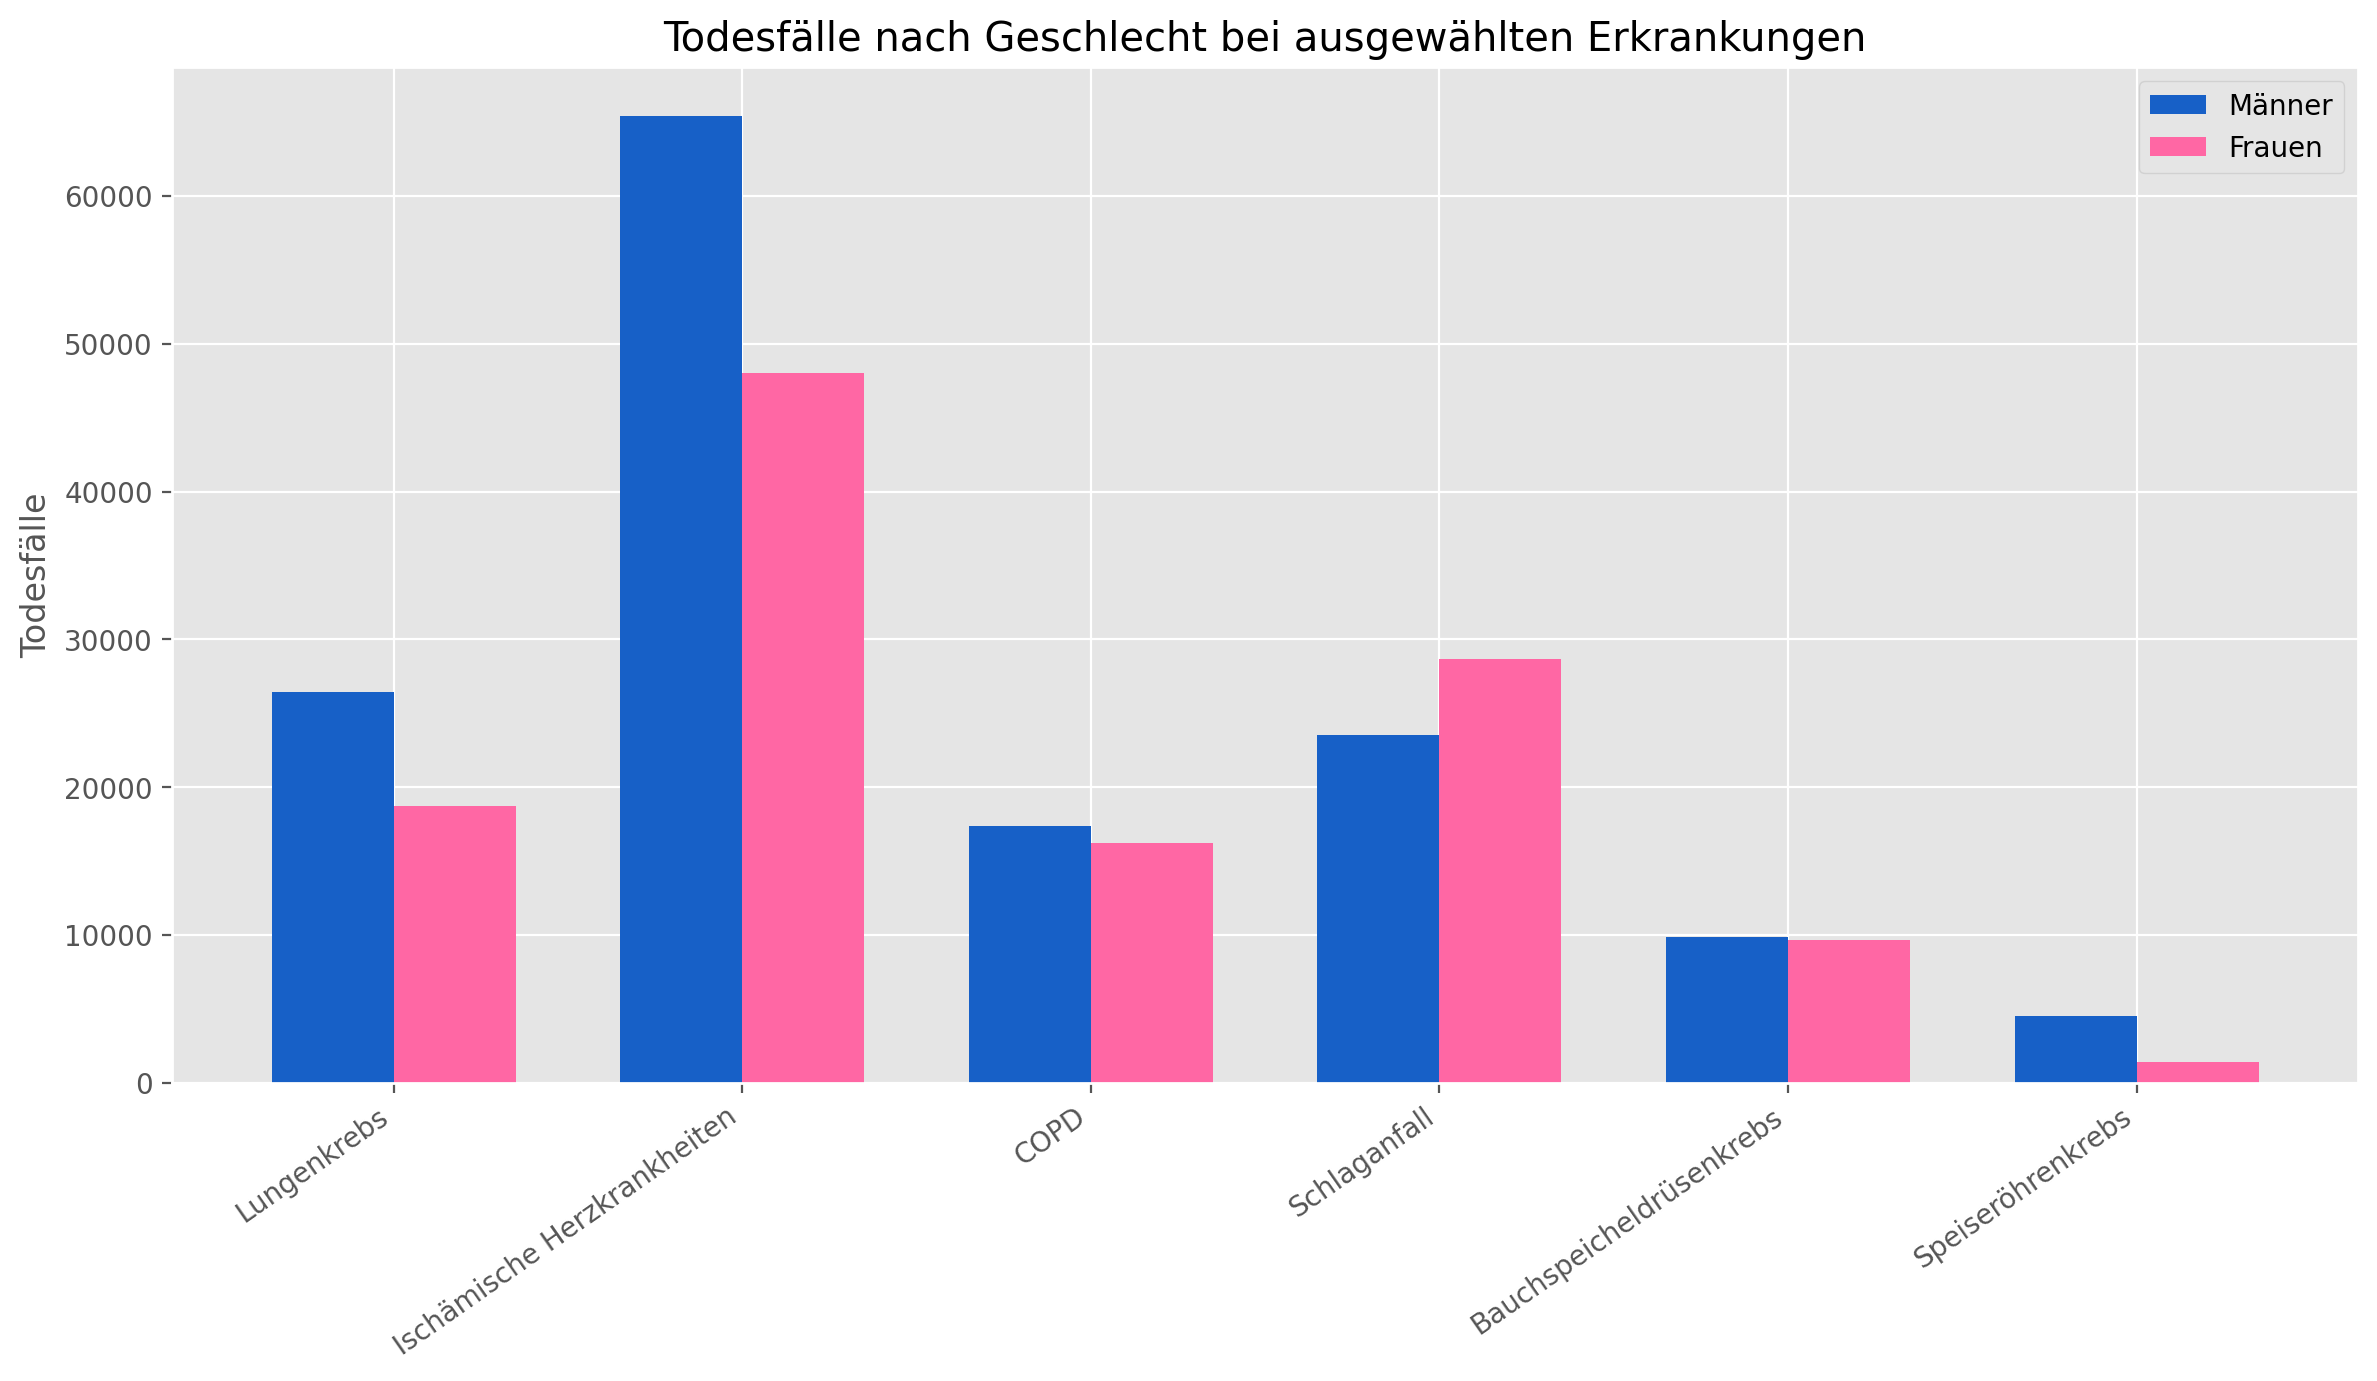

In [7]:
from IPython.display import Image, display

display(Image("Grafen/02_Sterblichkeit_nach_Geschlecht.png"))

Abbildung 2 zeigt die registrierten Todesfälle von Männern und Frauen bei den untersuchten Erkrankungen. Dadurch werden geschlechtsspezifische Unterschiede in der Sterblichkeit sichtbar. -->

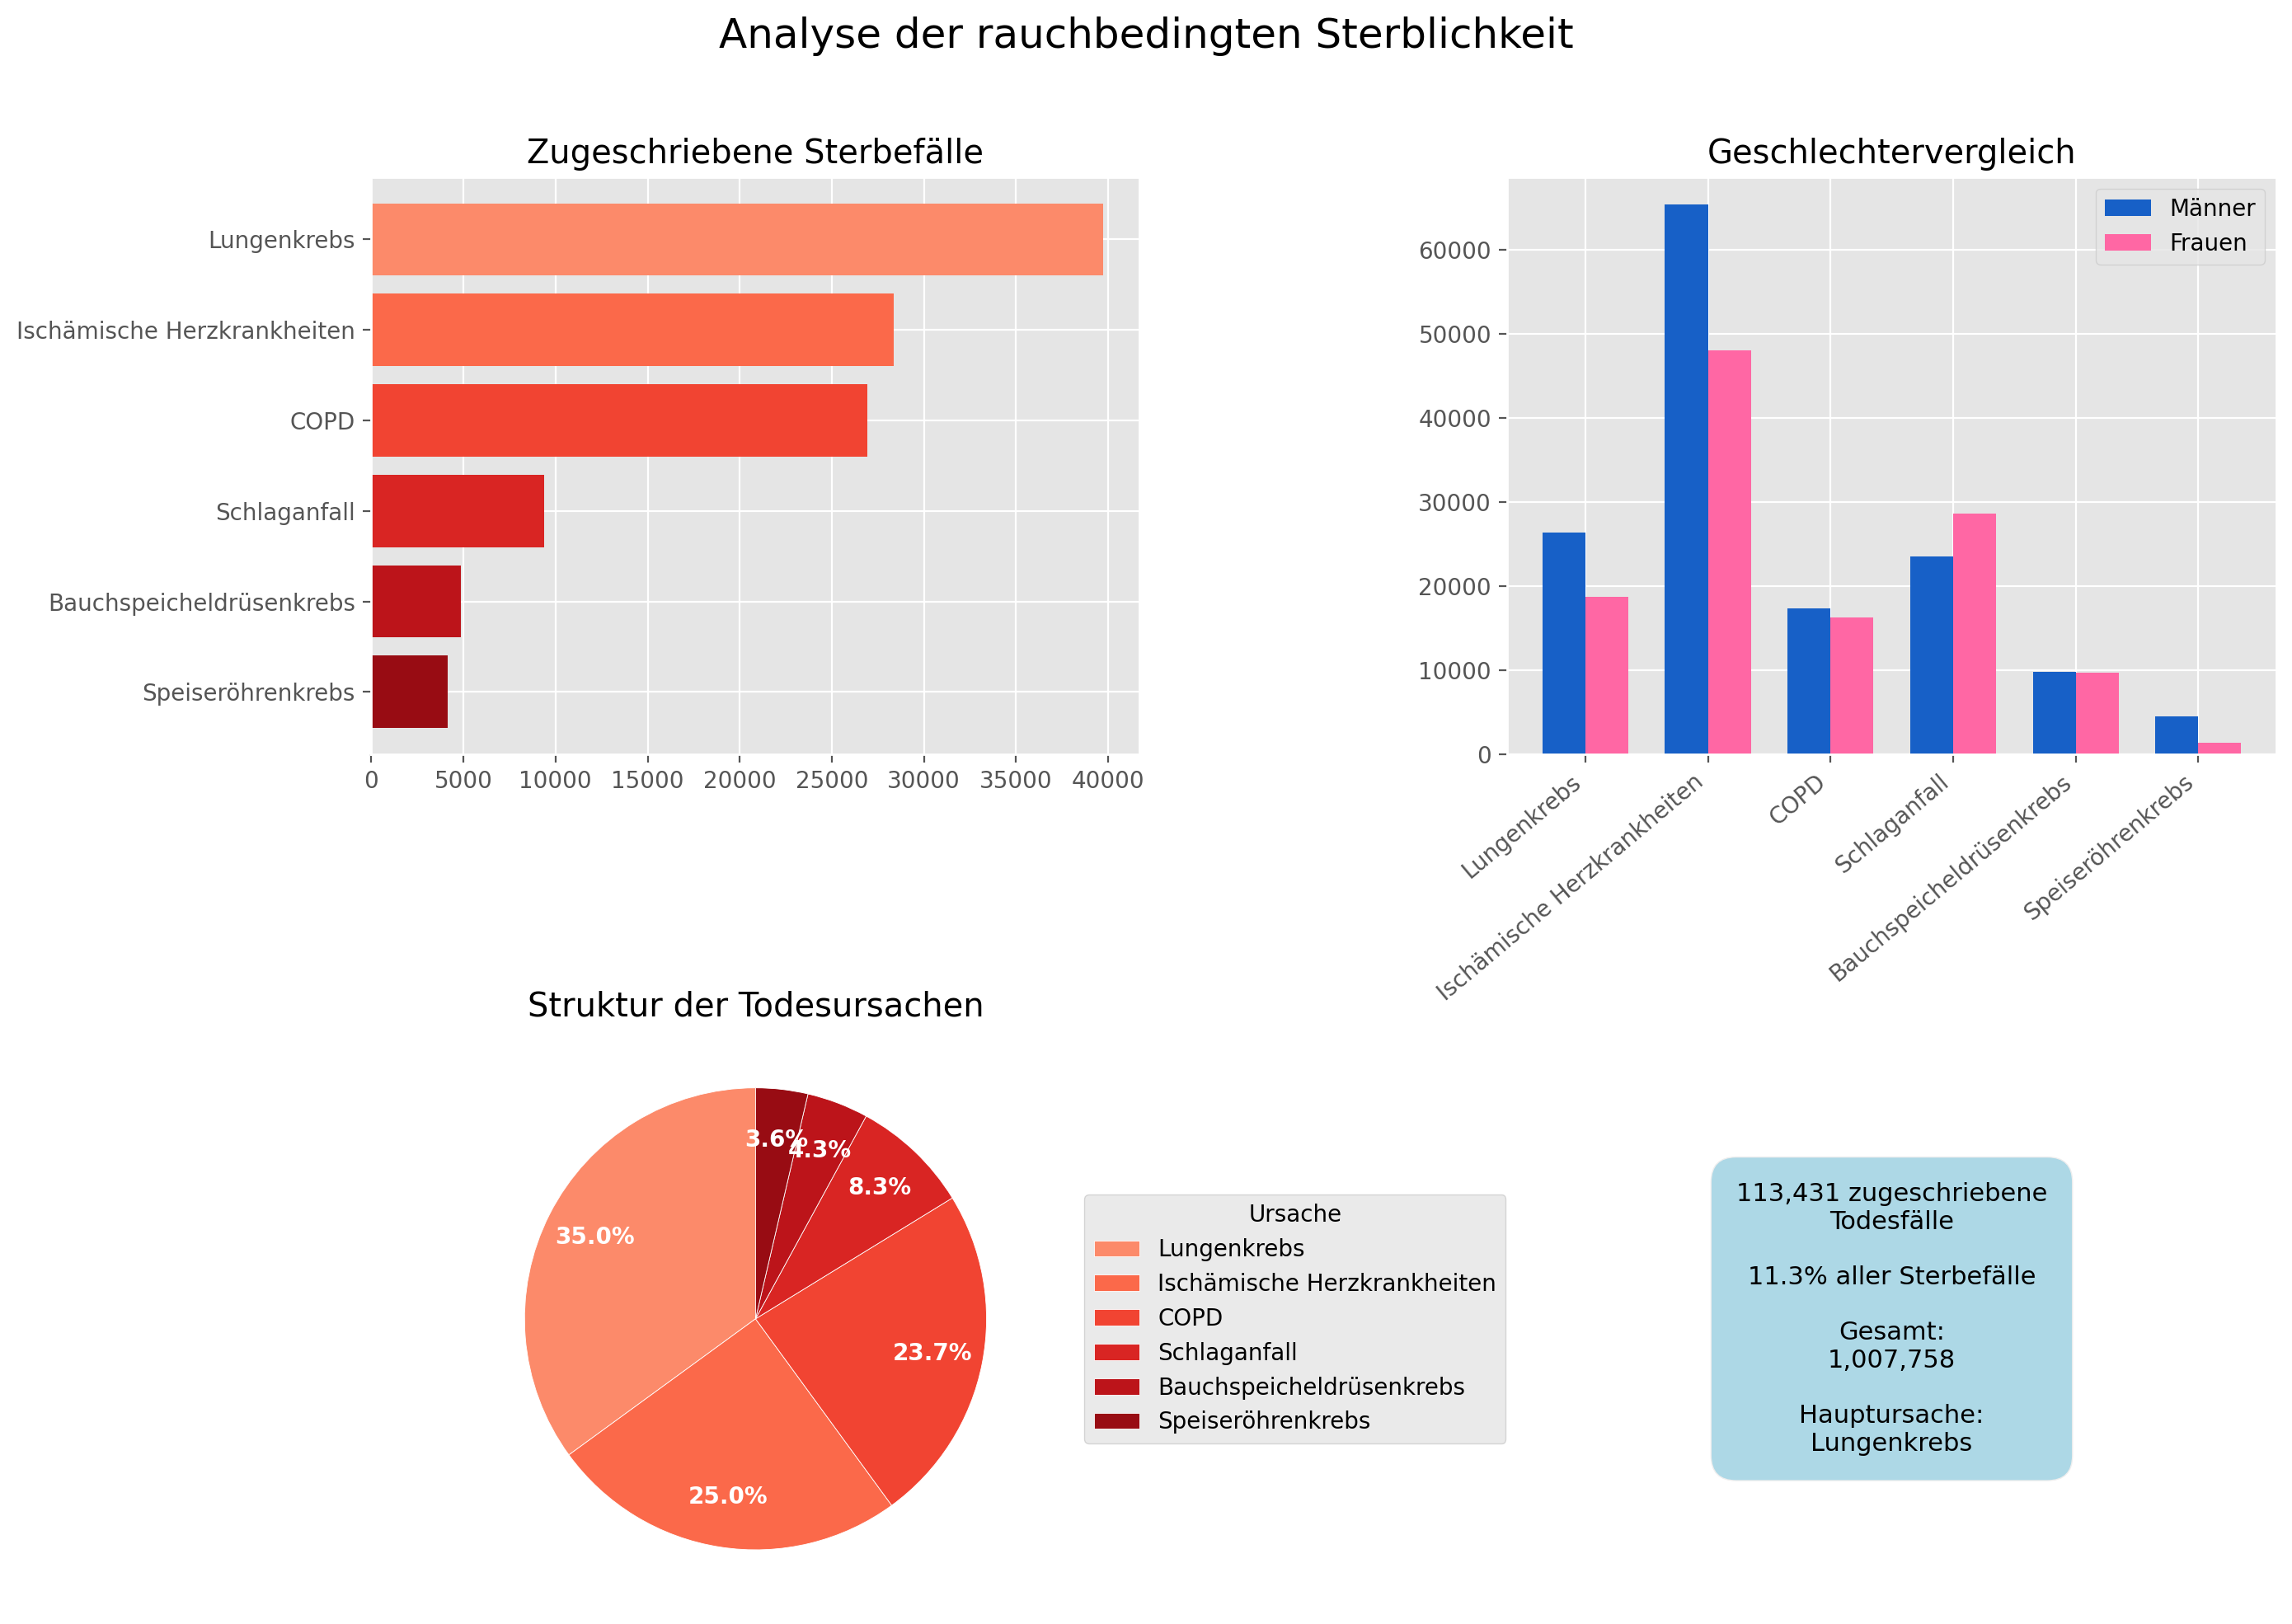

In [8]:
from IPython.display import Image, display

display(Image("Grafen/04_Gesamtanalyse_Rauchbedingte_Sterblichkeit.png"))

## Fazit

Die Analyse zeigt, dass rauchassoziierte Erkrankungen einen bedeutenden Anteil an der Sterblichkeit in Deutschland haben. Mithilfe des SAF-Modells wurden für das Jahr 2024 rund 113.431 tabakassoziierte Todesfälle geschätzt, was etwa 11,26 % aller Todesfälle entspricht.

Damit zählt Rauchen weiterhin zu den wichtigsten vermeidbaren Gesundheitsrisiken.